In [ ]:
!git clone https://github.com/anjanatalapatra/perovskite_oxide_discovery.git


Cloning into 'perovskite_oxide_discovery'...
remote: Enumerating objects: 264, done.
remote: Counting objects: 100% (73/73), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 264 (delta 32), reused 52 (delta 22), pack-reused 191 (from 1)
Receiving objects: 100% (264/264), 4.93 MiB | 10.05 MiB/s, done.
Resolving deltas: 100% (129/129), done.


In [ ]:
!pip install unicodecsv forestci seaborn
!pip install pdpbox



In [ ]:
# Change directory into the repo
%cd perovskite_oxide_discovery

/content/perovskite_oxide_discovery


In [ ]:
!sed -i 's/from scipy import interp/from numpy import interp/' perovmldis/ML_utilities/performance_functions.py


In [ ]:
import sys
sys.path.append('/content/perovskite_oxide_discovery')


In [ ]:
import pickle
import pandas as pd
import sys
sys.path.append('/content/perovskite_oxide_discovery')

import perovmldis.engine as en
from perovmldis.data_utilities.generate_data import generate_feature_labels, csv_to_json, prepare_data


ERROR:duecredit:Failed to import duecredit due to No module named 'duecredit'


###  Next, we load our training compounds and elemental data

In [ ]:
with open('data/training_compounds.pkl', 'rb') as f:
                training_compounds = pickle.load(f)
with open('data/element_data.pkl', 'rb') as f:
                ele_data = pickle.load(f)

In [ ]:
ele_data['Al'].keys()

dict_keys(['Electrical resistivity', 'Electronic structure', 'Oxidation states', 'energy', 'Reflectivity', 'Ele', 'LUMO', 'NMR Quadrupole Moment', 'HOMO', 'Van der waals radius', 'mulliken_EN', 'ICSD oxidation states', 'Metallic radius', 'Z_radii', 'Mineral hardness', 'Atomic mass', 'orbital_electrons', 'Atomic no', 'shannon_IR', 'atomic_mass', 'e_affin', 'Boiling point', 'Common oxidation states', 'Brinell hardness', 'Density of solid', 'row', 'Thermal conductivity', 'Critical temperature', 'Melting point', 'Mendeleev no', 'Liquid range', 'Coefficient of linear thermal expansion', 'Poissons ratio', 'Youngs modulus', 'Bulk modulus', 'Rigidity modulus', 'Velocity of sound', 'X', 'Z', 'IE', 'Atomic radius calculated', 'group', 'Vickers hardness', 'Superconduction temperature', 'Molar volume', 'Refractive index', 'Ionic radii', 'MJ_EN', 'Shannon radii', 'ionic_radii', 'Name', 'Atomic orbitals', 'atomic_radius', 'Atomic radius', 'EA', 'EA_final'])

In [ ]:
training_compounds[10].keys()

dict_keys(['A1', 'A1_CN', 'A1_OS', 'A2', 'A2_OS', 'B1', 'B1_OS', 'B2', 'B2_OS', 'Insulator', 'PBE_band_gap', 'functional_group', 'mu_bar', 'stable', 'type', 'data_type'])

### Then, we populate the training data with all the features we have finalized

In [ ]:
dft_training_data = en.create_perovskite_stability_training_data(training_compounds, ele_data)

In [ ]:
training_compounds[10].keys()

dict_keys(['A1', 'A1_CN', 'A1_OS', 'A2', 'A2_OS', 'B1', 'B1_OS', 'B2', 'B2_OS', 'Insulator', 'PBE_band_gap', 'functional_group', 'mu_bar', 'stable', 'type', 'data_type', 'A1_HOMO', 'A1_LUMO', 'A1_IE', 'A1_X', 'A1_e_affin', 'A1_Z_radii', 'A2_HOMO', 'A2_LUMO', 'A2_IE', 'A2_X', 'A2_e_affin', 'A2_Z_radii', 'B1_HOMO', 'B1_LUMO', 'B1_IE', 'B1_X', 'B1_e_affin', 'B1_Z_radii', 'B2_HOMO', 'B2_LUMO', 'B2_IE', 'B2_X', 'B2_e_affin', 'B2_Z_radii', 'A1_IR', 'A2_IR', 'B1_IR', 'B2_IR', 'tau', 'mu', 'mu_A_bar', 'mu_B_bar', 'A_HOMO_sum', 'A_HOMO_diff', 'A_LUMO_sum', 'A_LUMO_diff', 'A_IE_sum', 'A_IE_diff', 'A_X_sum', 'A_X_diff', 'A_e_affin_sum', 'A_e_affin_diff', 'A_Z_radii_sum', 'A_Z_radii_diff', 'B_HOMO_sum', 'B_HOMO_diff', 'B_LUMO_sum', 'B_LUMO_diff', 'B_IE_sum', 'B_IE_diff', 'B_X_sum', 'B_X_diff', 'B_e_affin_sum', 'B_e_affin_diff', 'B_Z_radii_sum', 'B_Z_radii_diff'])

In [ ]:
training_compounds[1200]

{'A1': 'Ho',
 'A1_CN': 12,
 'A1_OS': 3,
 'A2': 'Ho',
 'A2_OS': 3,
 'B1': 'Dy',
 'B1_OS': 3,
 'B2': 'Tm',
 'B2_OS': 3,
 'Insulator': 1,
 'PBE_band_gap': 1.3779,
 'functional_group': 'Ho2DyTmO6',
 'mu_bar': 0.0,
 'stable': 0,
 'type': 'A2B1B2O6',
 'data_type': 's',
 'A1_HOMO': -2.261,
 'A1_LUMO': -2.252,
 'A1_IE': 580.8,
 'A1_X': 1.23,
 'A1_e_affin': 32.61,
 'A1_Z_radii': 3.65,
 'A2_HOMO': -2.261,
 'A2_LUMO': -2.252,
 'A2_IE': 580.8,
 'A2_X': 1.23,
 'A2_e_affin': 32.61,
 'A2_Z_radii': 3.65,
 'B1_HOMO': -2.507,
 'B1_LUMO': -2.247,
 'B1_IE': 572.2,
 'B1_X': 1.22,
 'B1_e_affin': 33.96,
 'B1_Z_radii': 3.67,
 'B2_HOMO': -2.042,
 'B2_LUMO': -1.922,
 'B2_IE': 596.3,
 'B2_X': 1.25,
 'B2_e_affin': 99,
 'B2_Z_radii': 3.6,
 'A1_IR': 1.234,
 'A2_IR': 1.234,
 'B1_IR': 0.912,
 'B2_IR': 0.88,
 'tau': 0.8112,
 'mu': 0.64,
 'mu_A_bar': 0.0,
 'mu_B_bar': 0.01143,
 'A_HOMO_sum': -2.261,
 'A_HOMO_diff': np.float64(0.0),
 'A_LUMO_sum': -2.252,
 'A_LUMO_diff': np.float64(0.0),
 'A_IE_sum': 580.8,
 'A_IE_diff'

## Classification of oxide perovskites into narrow and wide band gap materials

### Use the training data to train the classification model. We also print out the performance metrics, confusion matrices (we use a 80/20 split for training and testing)  and plot the feature importances

------------------------------------------------------------------------
Insulator classification Model Performance
------------------------------------------------------------------------
RFC Test Precision: 0.9236641221374046
RFC Test Recall: 0.8581560283687943
RFC Test Accuracy: 0.9418604651162791
Test confusion matrix
[[365  10]
 [ 20 121]]
Train confusion matrix
[[3200    2]
 [  15 1419]]
 All data confusion matrix
[[3565   12]
 [  35 1540]]
------------------------------------------------------------------------


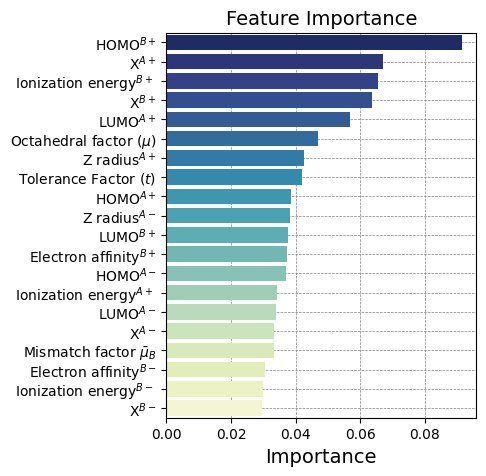

In [ ]:
insulator_feature_list, test_features,test_labels,insulator_clf = en.run_insulator_classification(dft_training_data)

## Next, we analyze the performance of our classification model, my plotting the performance curves:

i) The Receiver Operating Characteristic (ROC) curve

ii) Precision Recall (PR) curve

Ideally, you will spend some time fine tuning your model, adding more training data if necessary, until you are satisfied with the performance. Here we show our finished models.

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       375
           1       0.92      0.86      0.89       141

    accuracy                           0.94       516
   macro avg       0.94      0.92      0.93       516
weighted avg       0.94      0.94      0.94       516



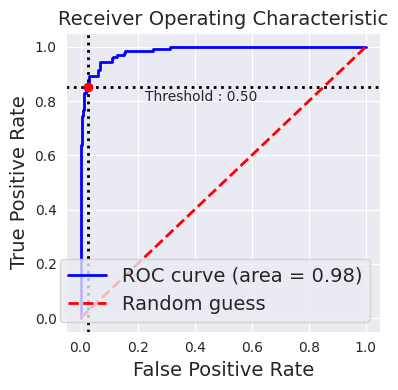

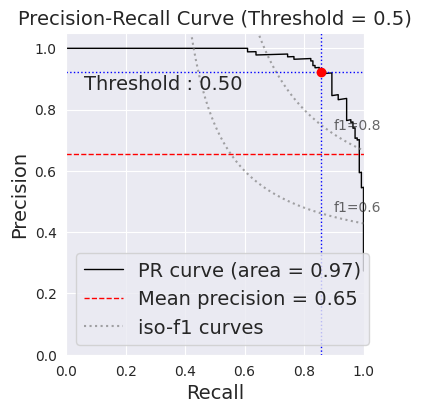

In [ ]:
from perovmldis.ML_utilities.ML_plotting import plot_roc_curves
plot_roc_curves(test_features,test_labels, insulator_clf)

## Regression model to predict band gap  of oxide perovskites expected to have a wide band gap

### First, we extract the training data for band gap regression. We train the regression model only using those data which have a wide band gap ( > 0.5 eV)


In [ ]:
bandgap_training_data = en.create_bandgap_regression_training_data(training_compounds, ele_data)

## Plot the training data

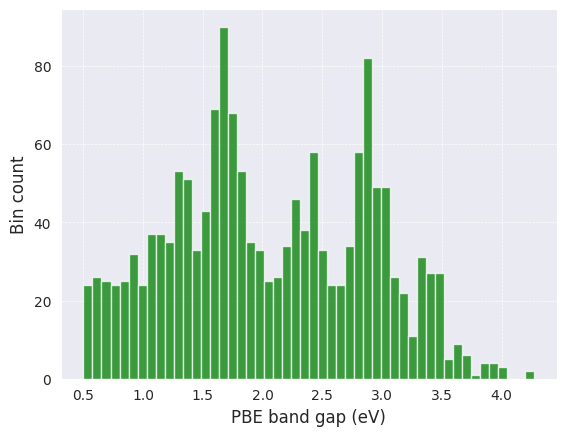

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
plot_data = pd.DataFrame(bandgap_training_data)
fig, ax = plt.subplots()
x = plot_data['PBE_band_gap'].values
n, bins, patches = plt.hist(x, 50, facecolor='g', alpha=0.75)
plt.xlabel('PBE band gap (eV)',fontsize=12)
plt.ylabel('Bin count',fontsize=12)
plt.grid(linestyle='--', linewidth='0.5')

##  Use the training data to train the regression model.

### We also print out the performance metrics and plot the feature importances, the parity curves for training and testing and the confidence intervals

We use a 80/20 split for training and testing

Band gap regression metrics:
  MSE Test: 0.1204
  MSE Train: 0.0196
  R^2 Test: 0.8001
  R^2 Train: 0.9716
  R2 Test: 0.8001


TypeError: 'int' object is not subscriptable

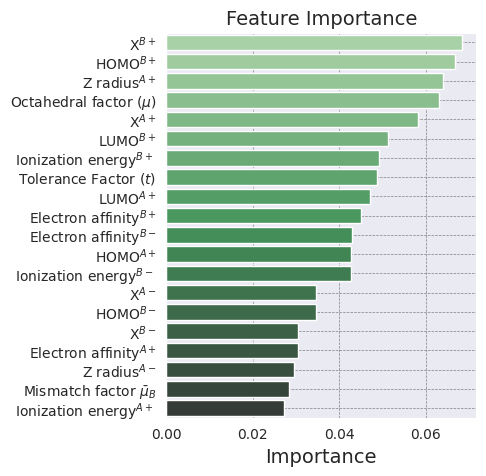

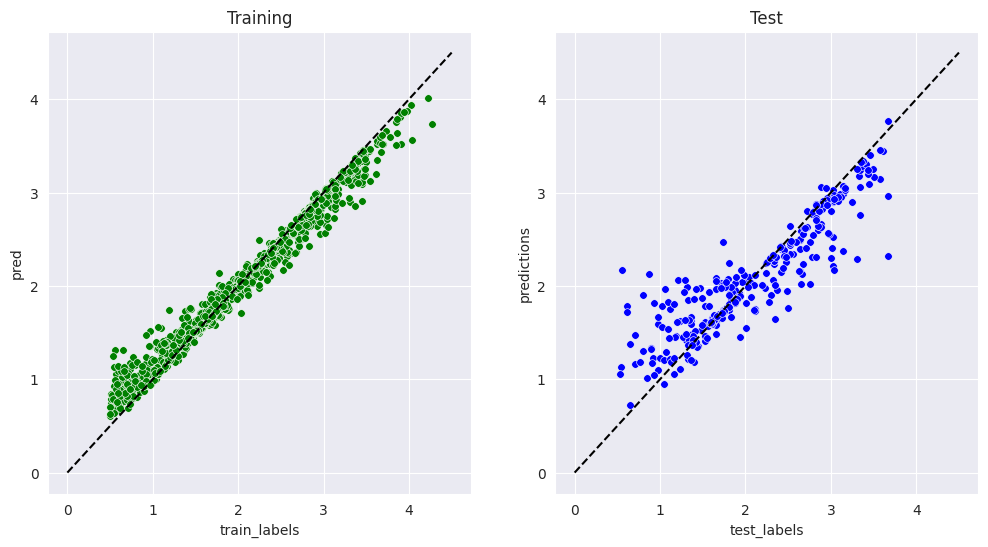

In [ ]:
regression_feature_list, best_estimator = en.run_bandgap_regression(bandgap_training_data)

## Predict new oxide perovskites with wide band gap

In [ ]:
all_candidates = csv_to_json('data/stable_formable_candidates.csv')
print(len(all_candidates))

476291


### This is a very large dataset that contains ~500,000 compounds, too large to use in this notebook. So for the purpose of demonstration, we proceed with only 100,000 candidates.

In [ ]:
condensed_candidate_data = all_candidates[0:100000]
all_candidate_data = prepare_data(condensed_candidate_data,ele_data)

### To speed things up, we clear some memory by deleting some data we no longer need

In [ ]:
del all_candidates
import gc
gc.collect()

26990

In [ ]:
from perovmldis.ML_utilities.RFC_functions import classify_data
insulator_candidates = classify_data(all_candidate_data, insulator_feature_list, insulator_clf, pred_label='predicted_Insulator', data_type='prediction', model_type='insulator')

Classify candidates
Number of compounds: 100000
Number of classified True compounds: 2999


### Of the 1350216 candidates, 16950 are predicted to be insulators

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import forestci as fci
import matplotlib.pyplot as plt

def preprocess_dataframe(df, target='PBE_band_gap'):
    df = df.copy()
    for col in df.columns:
        if df[col].dtype == 'object':  # string columns
            # Ensure the column is entirely string before applying LabelEncoder
            df[col] = df[col].astype(str)
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col])
    return df

def run_custom_bandgap_regression(df):
    df = preprocess_dataframe(df)
    target = 'PBE_band_gap'
    features = df.drop(columns=[target])
    labels = df[target]

    X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)
    train_predictions = model.predict(X_train)

    print("Band gap regression metrics:")
    print(f"  MSE Test: {mean_squared_error(y_test, predictions):.4f}")
    print(f"  MSE Train: {mean_squared_error(y_train, train_predictions):.4f}")
    print(f"  R^2 Test: {r2_score(y_test, predictions):.4f}")
    print(f"  R^2 Train: {r2_score(y_train, train_predictions):.4f}")

    return features.columns.tolist(), model, X_train, X_test, y_test, predictions

import numpy as np
import matplotlib.pyplot as plt
import forestci as fci
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier  # Ensure both are imported

# Example usage
bandgap_training_data_df = pd.DataFrame(bandgap_training_data)
regression_feature_list, model, X_train, X_test, y_test, predictions = run_custom_bandgap_regression(bandgap_training_data_df)





Band gap regression metrics:
  MSE Test: 0.1290
  MSE Train: 0.0168
  R^2 Test: 0.8256
  R^2 Train: 0.9745


In [ ]:
# Example usage
bandgap_training_data_df = pd.DataFrame(bandgap_training_data)

# Run the custom bandgap regression to get the trained model and other outputs
regression_feature_list, model, X_train, X_test, y_test, predictions = run_custom_bandgap_regression(bandgap_training_data_df)

# Define best_estimator here as the trained model
best_estimator = model

# Now you can use 'best_estimator' for making predictions or any further analysis
print(best_estimator)


Band gap regression metrics:
  MSE Test: 0.1290
  MSE Train: 0.0168
  R^2 Test: 0.8256
  R^2 Train: 0.9745
RandomForestRegressor(random_state=42)


In [ ]:
from perovmldis.ML_utilities.RFR_functions import predict_regression
from sklearn.preprocessing import LabelEncoder

# Create a LabelEncoder instance
label_encoder = LabelEncoder()

# Get a list of features that are string type
categorical_features = insulator_candidates.select_dtypes(include=['object']).columns.tolist()

# Encode the categorical features
for feature in categorical_features:
    # Ensure the column is entirely string before applying LabelEncoder
    insulator_candidates[feature] = insulator_candidates[feature].astype(str)
    insulator_candidates[feature] = label_encoder.fit_transform(insulator_candidates[feature])

# Instead of using set intersection, select only features present in both lists:
common_features = [feature for feature in regression_feature_list if feature in insulator_candidates.columns]

# Ensure all features used during training are present in the prediction data:
for feature in regression_feature_list:
    if feature not in insulator_candidates.columns:
        insulator_candidates[feature] = 0  # or any appropriate default value

# Use only the common features for prediction
wide_bandgap_data = predict_regression(insulator_candidates, regression_feature_list, best_estimator, pred_label='Predicted_band_gap')  # Use regression_feature_list here

Number of compounds: 2999
Number of wide bandgap compounds: 2999


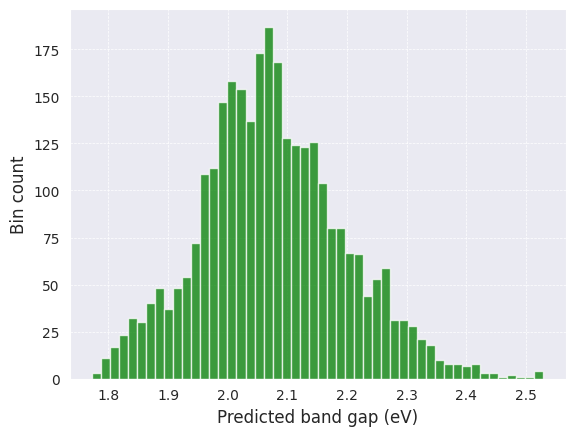

In [ ]:
plot_predicted_data = pd.DataFrame(wide_bandgap_data)
fig, ax = plt.subplots()
x = plot_predicted_data['Predicted_band_gap'].values
n, bins, patches = plt.hist(x, 50, facecolor='g', alpha=0.75)
plt.xlabel('Predicted band gap (eV)',fontsize=12)
plt.ylabel('Bin count',fontsize=12)
plt.grid(linestyle='--', linewidth='0.5')

## More analysis: Partial Dependence Plots (PDPs)

In [ ]:
def generate_feature_labels(feature_list):
    f_list = [
        'A_HOMO_diff','A_HOMO_sum','A_IE_diff','A_IE_sum','A_LUMO_diff','A_LUMO_sum','A_X_diff','A_X_sum','A_Z_radii_diff','A_Z_radii_sum','A_e_affin_diff',
        'A_e_affin_sum','B_HOMO_diff','B_HOMO_sum','B_IE_diff','B_IE_sum','B_LUMO_diff','B_LUMO_sum','B_X_diff','B_X_sum','B_Z_radii_diff','B_Z_radii_sum','B_e_affin_diff',
        'B_e_affin_sum','mu','mu_A_bar','mu_B_bar','tau','B2_IR','A1_X','B1_LUMO'
    ]

    label_list = [
        'HOMO$^{A-}$', 'HOMO$^{A+}$', 'Ionization energy$^{A-}$ ', 'Ionization energy$^{A+}$ ', 'LUMO$^{A-}$', 'LUMO$^{A+}$', 'X$^{A-}$', 'X$^{A+}$',
        'Z radius$^{A-}$', 'Z radius$^{A+}$', 'Electron affinity$^{A-}$', 'Electron affinity$^{A+}$',
        'HOMO$^{B-}$', 'HOMO$^{B+}$', 'Ionization energy$^{B-}$ ', 'Ionization energy$^{B+}$ ',
        'LUMO$^{B-}$', 'LUMO$^{B+}$', 'X$^{B-}$', 'X$^{B+}$', 'Z radius$^{B-}$', 'Z radius$^{B+}$', 'Electron affinity$^{B-}$', 'Electron affinity$^{B+}$',
        'Octahedral factor ($\mu$)', 'Mismatch factor $\\bar{\\mu}_A$', 'Mismatch factor $\\bar{\\mu}_B$', 'Tolerance Factor ($t$)',
        'IR$^{B_2}$', 'X$^{A_1}$', 'LUMO$^{B_1}$'
    ]

    if len(f_list) != len(label_list):
        raise ValueError(f"Length mismatch: f_list has {len(f_list)}, label_list has {len(label_list)}")

    # Safety check
    missing_features = [feat for feat in feature_list if feat not in f_list]
    if missing_features:
        print("❌ Missing features (not in f_list):", missing_features)
        return []

    fn_list = [f_list.index(i) for i in feature_list]
    feature_labels = [label_list[i] for i in fn_list]
    return feature_labels


In [ ]:
ranked_labels = generate_feature_labels(ranked_features)
print("✅ Ranked Labels:", ranked_labels)


✅ Ranked Labels: ['IR$^{B_2}$', 'X$^{A_1}$', 'X$^{B+}$', 'LUMO$^{B_1}$', 'HOMO$^{B+}$']


In [ ]:
importances = list(best_estimator.feature_importances_)
feature_importances = [(feature, round(importance, 5)) for feature, importance in zip(regression_feature_list, importances)]
feature_importances = sorted(feature_importances, key = lambda x: x[1], reverse = True)
ranked_features = []
for i in range(5):
    ranked_features.append(feature_importances[i][0])
dataset = pd.DataFrame(bandgap_training_data)
ranked_labels = generate_feature_labels(ranked_features)
print(ranked_labels)

['IR$^{B_2}$', 'X$^{A_1}$', 'X$^{B+}$', 'LUMO$^{B_1}$', 'HOMO$^{B+}$']
